In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [21]:
constant = 5.67037 * 10**-8
T = np.arange(250, 10000, 250)
E = constant * T**4

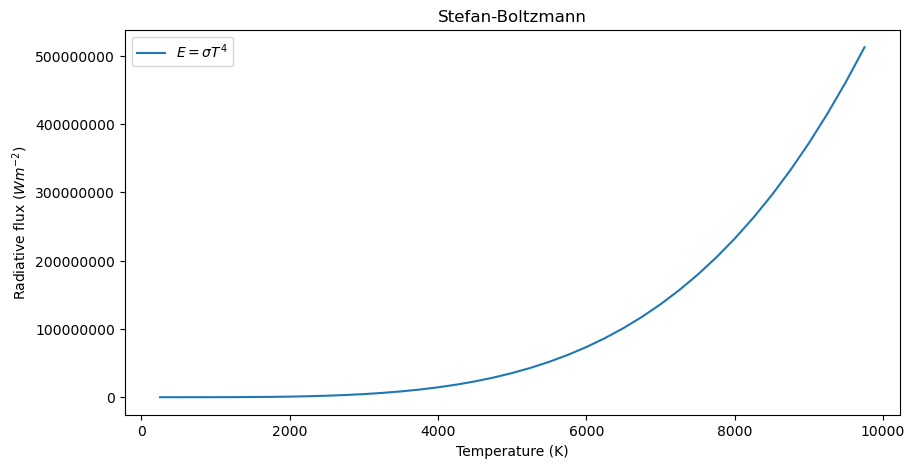

In [23]:
plt.figure(figsize=(10,5))
plt.plot(T, E, label=r'$E = \sigma T^4$')
plt.title('Stefan-Boltzmann')
plt.xlabel('Temperature (K)')
plt.ylabel(r'Radiative flux ($Wm^{-2}$)')
plt.legend()
plt.ticklabel_format(style='plain', axis='both')
# plt.xlim(0,1000)
# plt.ylim(0,10000)
plt.show()

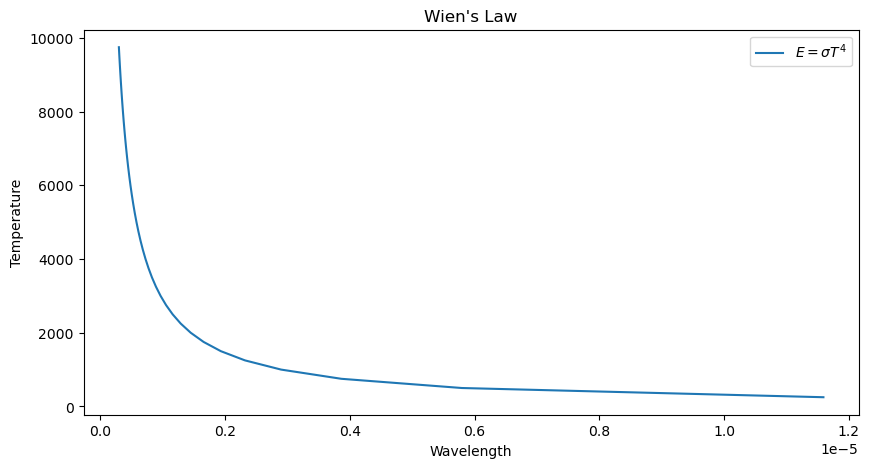

In [31]:
# Wein's law

wein_constant = 2.897771955e-3

# lambda = b/T

peak_wavelengths = wein_constant/T

plt.figure(figsize=(10,5))
plt.plot(peak_wavelengths, T, label=r'$E = \sigma T^4$')
plt.title("Wien's Law")
plt.xlabel('Wavelength')
plt.ylabel(r'Temperature')
plt.legend()
plt.ticklabel_format(style='scientific', axis='x')
# plt.xlim(0,1000)
# plt.ylim(0,10000)
plt.show()


In [ ]:
# Physical constants
h = 6.626e-34   # Planck's constant = 6.626e-34 Js
c = 3.0e8       # Speed of light = 3.0e8 m/s
k = 1.381e-23   # Boltzmann constant = 1.381e-23
b = 2.898e-3    # Wien's constant

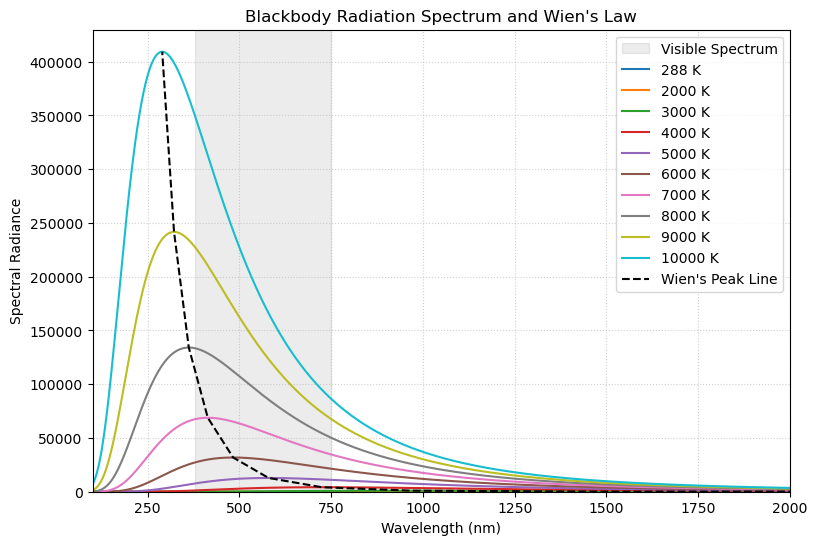

In [ ]:
# define function

def planck(wavelength_m, T_k):
    a = 2.0 * h * c**2
    b_val = (h*c) / (wavelength_m * k * T_k)
    return a / (wavelength_m**5 * (np.exp(b_val) -1 ))

wavelengths_nm = np.linspace(100, 2000, 1000)
wavelengths_m = wavelengths_nm * 1e-9

# Temperature range
temperatures = [288, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

plt.figure(figsize=(9, 6))

# Highlight Visible Spectrum (380 nm - 750 nm)
plt.axvspan(380, 750, color='gray', alpha=0.15, label='Visible Spectrum')

# Plot Planck curves and track peaks
peak_wavelengths = []
peak_intensities = []

for T in temperatures:
    intensity = planck(wavelengths_m, T) / 1e9  # Scale for plotting
    plt.plot(wavelengths_nm, intensity, label=f'{T} K')
    
    # Calculate Wien's peak
    lam_max = b / T
    intensity_max = planck(lam_max, T) / 1e9
    peak_wavelengths.append(lam_max * 1e9)
    peak_intensities.append(intensity_max)

# Plot Wien's Displacement Law line through peaks
plt.plot(peak_wavelengths, peak_intensities, 'k--', label="Wien's Peak Line")

# Labels and formatting
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Radiance')
plt.title("Blackbody Radiation Spectrum and Wien's Law")
plt.xlim(100, 2000)
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()